### 1. Importación de Librerías Numéricas
Carga de NumPy y utilidades para manipulación de arreglos.

In [58]:
import numpy as np
import tensorflow as tf
from keras import layers, models
import pygad

import csv
import os
import gc

from keras import backend as K

import warnings


from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd



### 2. Importación de Módulos Aleatorios
Carga de librerías para generación de números pseudoaleatorios.

In [59]:
import random

def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Para asegurar operaciones deterministas en la GPU (opcional, puede ser más lento)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)

set_reproducibility(42)

### 3. Configuración de Advertencias
Supresión de mensajes de advertencia innecesarios durante la ejecución.

In [60]:
warnings.filterwarnings('ignore')

### 4. Definición del Espacio de Genes
Configuración de los rangos y valores posibles para la optimización de hiperparámetros (neuronas, learning rate, activación, dropout).

In [ ]:
gene_space = [
    {"low": 32, "high": 512,"step": 32},        # Número de neuronas
    {"low": 0, "high": 3, "step": 1},           # Para elegir la función de activación
    {"low": -5, "high": -3},                    # Tasa de aprendizaje
    {"low": 0.1, "high": 0.4}                   # Dropout
]

### 5. Construcción de Arquitectura Dinámica
Definición de la función para crear modelos neuronales basados en los hiperparámetros recibidos.

In [62]:
def build_model(n_neurons, lr, activation, dropout):
    # Crea la cabeza del modelo
    model = models.Sequential([
        layers.Input(shape=(1280,)),                        # La entrada es un vector de 1280 características
        layers.Dense(n_neurons, activation=activation),     # Capa oculta con el número de neuronas y función de activación elegidos
        layers.Dropout(dropout),                            # Capa de dropout con la tasa elegida
        layers.Dense(4, activation='softmax')               # Capa de salida con 4 neuronas (para 4 clases) y función de activación softmax
    ])

    # El learning rate entra en el optimizador
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),   # Optimizador Adam con la tasa de aprendizaje elegida
        loss='sparse_categorical_crossentropy',                 # Función de pérdida para clasificación multiclase
        metrics=['accuracy']                                    # Métrica de precisión para evaluar el modelo durante el entrenamiento
    )

    # Al final, regresa el modelo
    return model

### 6. Decodificación de Cromosomas
Conversión de la solución numérica del algoritmo genético en valores de hiperparámetros legibles.

In [63]:
def decode_chromosome(solution):
    # Gen 0: Neuronas (Un entero)
    n_neurons = int(solution[0])

    # Gen 1: función de activación (Un entero que mapea a una función)
    activation = ['relu', 'tanh', 'sigmoid', 'elu'][int(solution[1])]

    # Gen 2: learning rate (Número flotante)
    lr = 10 ** solution[2]

    # Gen 3: Dropout (Número flotante)
    dropout = float(solution[3])

    # Regresa todos los parámetros
    return n_neurons, lr, activation, dropout

### 7. Configuración de Registro de Progreso
Definición de la ruta del archivo CSV para registrar la evolución de los individuos.

In [64]:
REGISTROS = 'csv_progreso/evolucion_individuosgenmodif.csv'

### 8. Preparación del Archivo CSV
Creación e inicialización del archivo de registros evolutivos.

In [65]:
def preparar_csv(nombre_archivo):
    carpeta = os.path.dirname(nombre_archivo)

    if carpeta and not os.path.exists(carpeta):
        os.makedirs(carpeta)
        print(f"Carpeta creada: {carpeta}")

    if not os.path.exists(nombre_archivo):
        with open(nombre_archivo, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([
                'Generacion', 'Individuo', 'n_neurons', 
                'learning_rate', 'activation', 'dropout', 'fitness'])

### 9. Carga de Datos Procesados
Lectura de los archivos de características almacenados (X_train_effnet.npy, etc.).

In [66]:
X_train_path = 'X_train_effnet.npy'
y_train_path = 'y_train_effnet.npy'
X_val_path = 'X_val_effnet.npy'
y_val_path = 'y_val_effnet.npy'

X_train = np.load(X_train_path)
y_train = np.load(y_train_path)

X_val = np.load(X_val_path)
y_val = np.load(y_val_path)

### 10. Inicialización de Registros
Preparación del archivo de seguimiento antes de arrancar el algoritmo genético.

In [67]:
preparar_csv(REGISTROS)

### 11. Función de Aptitud (Fitness)
Definición de la función de evaluación que entrena la red y retorna el accuracy de validación como puntaje de aptitud.

In [ ]:
def fitness_func(ga_instance, solution, solution_idx):
    # La fitness por default es 0
    fitness = 0.0
    model = None
    
    # 1. Se decodifica el cromosoma
    n_neurons, lr, activation, dropout = decode_chromosome(solution)
    generacion = ga_instance.generations_completed
    
    # 2. Entrenamiento
    # Solo se entrena por 15 épocas. Se usa un batch_size de 32
    try:
        # Se construye el modelo
        model = build_model(n_neurons, lr, activation, dropout)

        # Se entrena el modelo
        modelo = model.fit(
            X_train, y_train,
            epochs=13,
            batch_size=32,
            validation_data=(X_val, y_val),
            verbose=0
        )

        # Guardamos, como fitness, la máxima exactitud de validación 
        fitness = np.mean(modelo.history['val_accuracy'][-5:])  # Promedio de las últimas 5 épocas para una evaluación más estable
    # Si hubo parámetros invalidos, lo penaliza
    except Exception as e:
        fitness = 0.0

        # Pone todosl los parámetros como 0
        n_neurons, lr, activation, dropout = 0,0,0,0
    finally:
        # 3. Hacemos el registro en el csv 
        try:
            with open(REGISTROS, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([
                    generacion, solution_idx, n_neurons,
                    lr, activation, dropout, fitness
                ])
        except Exception as csv_error:
            print(f"Error al escribir en CSV: {csv_error}")

        # 4. Limpieza de la RAM
        # Esto debe ejecutarse aún si el modelo falló
        if model is not None:
            del model

        # Limpieza final
        K.clear_session()
        gc.collect()

    # Regresa la aptitud
    return fitness

### 12. Configuración e Inicio de PyGAD
Inicialización de la instancia del algoritmo genético (pygad.GA) y ejecución de la optimización.

In [69]:
ga_instance = pygad.GA(
    num_generations=55,                # Cuántas veces evoluciona
    num_parents_mating=5,              # Mejores individuos que se cruzan
    fitness_func=fitness_func,         # Tu función de entrenamiento
    sol_per_pop=23,                    # Individuos por generación
    num_genes=4,                       # Neuronas, Act, LR, Dropout
    gene_space=gene_space,
    parent_selection_type="tournament",       # Selección de estado estable
    K_tournament=3,                        # Tamaño del torneo
    keep_elitism=2,                    # Los 2 mejores pasan siempre de grado
    crossover_type="single_point",
    mutation_type="random",
    mutation_probability=0.15          # Un poco de caos para encontrar mejores rutas
)
ga_instance.run()

### 13. Obtención de la Mejor Solución
Extracción del mejor cromosoma y su puntuación de aptitud máxima.

In [70]:
solution, solution_fitness, solution_idx = ga_instance.best_solution()

### 14. Reporte de Resultados
Impresión en consola del accuracy de validación obtenido por la mejor solución.

In [71]:
print(f"Accuracy de validación: {solution_fitness}")

Accuracy de validación: 0.963328194618225


### 15. Extracción de Mejores Hiperparámetros
Decodificación del mejor cromosoma para obtener la configuración óptima final.

In [72]:
n_neurons, lr, activation, dropout = decode_chromosome(solution)

print(n_neurons, lr, activation, dropout)
final_model = build_model(n_neurons, lr, activation, dropout)

final_model.summary()

final_model.save('best_maiz.keras')

352 0.0002762550912235811 relu 0.34973279224012654


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 352)            │       450,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,412 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 452,324 (1.73 MB)

 Trainable params: 452,324 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

### 16. Configuración de Callbacks Evolutivos
Establecimiento de callbacks para el entrenamiento final con la arquitectura optimizada.

In [73]:


callbacks = [
    tf.keras.callbacks.ModelCheckpoint('mejor_modelo_maiz.keras', save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
]

modelo = final_model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=callbacks
)

Epoch 1/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9068 - loss: 0.2741 - val_accuracy: 0.9353 - val_loss: 0.1598
Epoch 2/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9636 - loss: 0.1055 - val_accuracy: 0.9384 - val_loss: 0.1309
Epoch 3/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9702 - loss: 0.0812 - val_accuracy: 0.9430 - val_loss: 0.1376
Epoch 4/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9785 - loss: 0.0680 - val_accuracy: 0.9399 - val_loss: 0.1445
Epoch 5/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9835 - loss: 0.0569 - val_accuracy: 0.9461 - val_loss: 0.1285
Epoch 6/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9851 - loss: 0.0514 - val_accuracy: 0.9507 - val_loss: 0.1222
Epoch 7/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9878 - loss: 0.0383 - val_accuracy: 0.9584 - val_loss: 0.1150
Epoch 8/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9894 - loss: 0.0336 - val_accuracy: 0.9584 - val_loss:

### 17. Carga del Conjunto de Prueba
Lectura de los datos de test para la evaluación final del modelo optimizado.

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


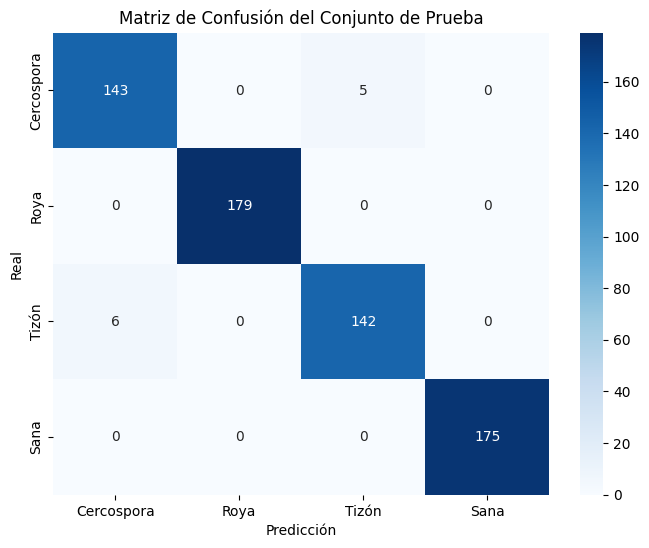

              precision    recall  f1-score   support

  Cercospora       0.96      0.97      0.96       148
        Roya       1.00      1.00      1.00       179
       Tizón       0.97      0.96      0.96       148
        Sana       1.00      1.00      1.00       175

    accuracy                           0.98       650
   macro avg       0.98      0.98      0.98       650
weighted avg       0.98      0.98      0.98       650



: 

In [ ]:
X_test, y_test = np.load('X_test_effnet.npy'), np.load('y_test_effnet.npy')

y_pred = np.argmax(final_model.predict(X_test), axis=1)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cercospora', 'Roya', 'Tizón', 'Sana'],
            yticklabels=['Cercospora', 'Roya', 'Tizón', 'Sana'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión del Conjunto de Prueba')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Cercospora', 'Roya',  'Tizón', 'Sana']))

### 18. Visualización del Historial Evolutivo
Definición de funciones para graficar curvas de aprendizaje y rendimiento.

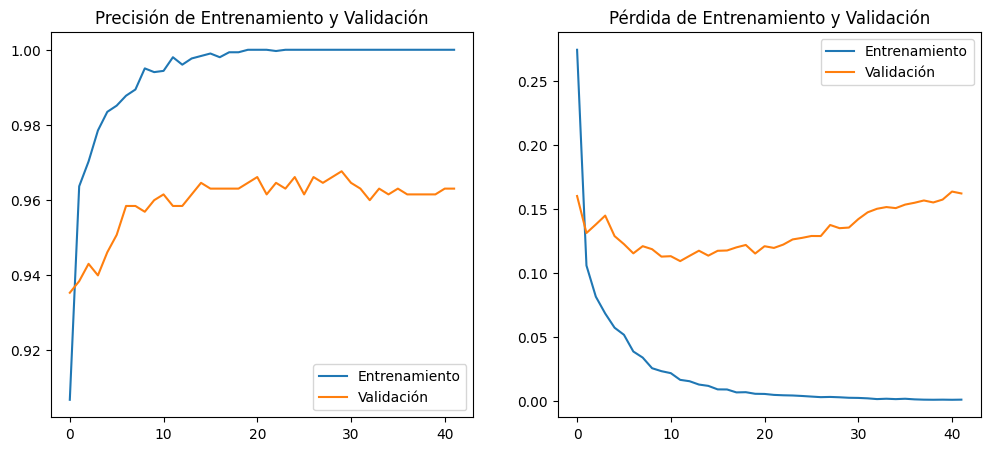

In [75]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Gráfico de Precisión
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Entrenamiento')
    plt.plot(epochs_range, val_acc, label='Validación')
    plt.title('Precisión de Entrenamiento y Validación')
    plt.legend()

    # Gráfico de Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Entrenamiento')
    plt.plot(epochs_range, val_loss, label='Validación')
    plt.title('Pérdida de Entrenamiento y Validación')
    plt.legend()
    plt.show()

plot_history(modelo)

### 19. Análisis de Registros Históricos
Lectura del archivo CSV con el progreso guardado de las generaciones del algoritmo genético.

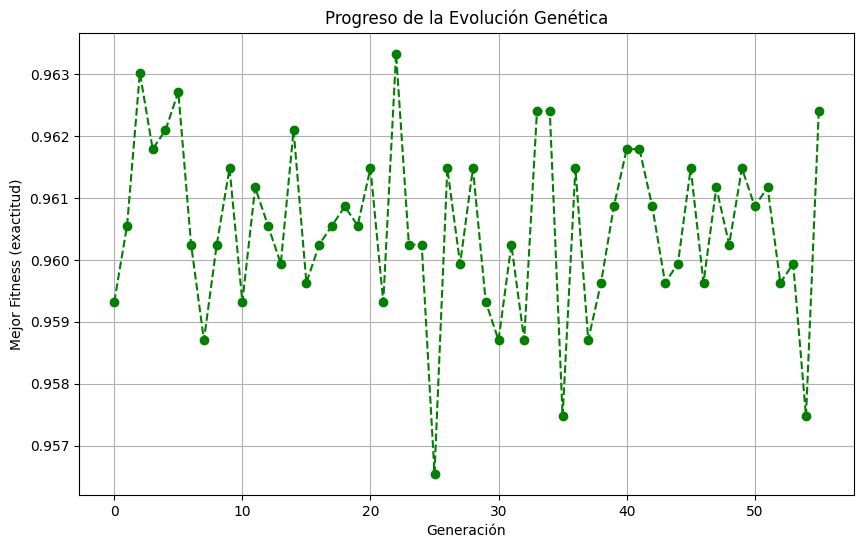

In [76]:
# Leer los registros que guardaste
df_evo = pd.read_csv(REGISTROS)
# Obtener el mejor fitness de cada generación
mejor_por_gen = df_evo.groupby('Generacion')['fitness'].max()

plt.figure(figsize=(10, 6))
plt.plot(mejor_por_gen.index, mejor_por_gen.values, marker='o', linestyle='--', color='green')
plt.title('Progreso de la Evolución Genética')
plt.xlabel('Generación')
plt.ylabel('Mejor Fitness (exactitud)')
plt.grid(True)
plt.show()

### 20. Carga del Mejor Modelo Guardado
Recuperación del modelo óptimo almacenado en disco (mejor_modelo_maiz.keras).

In [77]:
final_model = tf.keras.models.load_model('mejor_modelo_maiz.keras')

test_loss, test_acc = final_model.evaluate(X_test, y_test)
print(f"Exactitud Final en conjunto de prueba: {test_acc}")
print(f"Pérdida Final en conjunto de prueba: {test_loss}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9831 - loss: 0.0779  
Exactitud Final en conjunto de prueba: 0.9830769300460815
Pérdida Final en conjunto de prueba: 0.07786298543214798


### 21. Configuración Final del Modelo Óptimo
Definición de parámetros avanzados para el despliegue y uso del modelo evolucionado.

In [80]:
n_neurons_base = 512
lr_base = 0.001
activation_base = 'relu'
dropout_base = 0.15

model_baseline = build_model(n_neurons_base, lr_base, activation_base, dropout_base)

history_base = model_baseline.fit(
    X_train, y_train,
    epochs=60, # Usa las mismas épocas que en tu entrenamiento final
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

y_pred = np.argmax(model_baseline.predict(X_test), axis=1)

print(classification_report(y_test, y_pred, target_names=['Cercospora', 'Roya', 'Sana', 'Tizón']))

test_loss, test_acc = model_baseline.evaluate(X_test, y_test)
print(f"Exactitud en conjunto de prueba: {test_acc}")
print(f"Pérdida en conjunto de prueba: {test_loss}")

Epoch 1/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9395 - loss: 0.1680 - val_accuracy: 0.9476 - val_loss: 0.1193
Epoch 2/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9752 - loss: 0.0668 - val_accuracy: 0.9384 - val_loss: 0.1632
Epoch 3/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9845 - loss: 0.0452 - val_accuracy: 0.9430 - val_loss: 0.1365
Epoch 4/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9907 - loss: 0.0286 - val_accuracy: 0.9414 - val_loss: 0.1666
Epoch 5/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9950 - loss: 0.0189 - val_accuracy: 0.9414 - val_loss: 0.1663
Epoch 6/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9960 - loss: 0.0135 - val_accuracy: 0.9414 - val_loss: 0.1905
Epoch 7/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9977 - loss: 0.0106 - val_accuracy: 0.9291 - val_loss: 0.2633
Epoch 8/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.9137 - val_loss: